## **1. Raw Data Loading & Quality Diagnostics**

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "data" / "raw" / "oulad"
print(DATA_DIR)
print(list(DATA_DIR.iterdir()))

d:\VKU-Studying\Research - Modern DL Models\ati-dropout-prediction\data\raw\oulad
[WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/assessments.csv'), WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/courses.csv'), WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/studentAssessment.csv'), WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/studentInfo.csv'), WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/studentRegistration.csv'), WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/studentVle.csv'), WindowsPath('d:/VKU-Studying/Research - Modern DL Models/ati-dropout-prediction/data/raw/oulad/vle.csv')]


In [2]:
info = pd.read_csv(DATA_DIR / "studentInfo.csv")
reg = pd.read_csv(DATA_DIR / "studentRegistration.csv")
vle = pd.read_csv(DATA_DIR / "vle.csv")
courses = pd.read_csv(DATA_DIR / "courses.csv")

for name, df in [("studentInfo", info), ("studentRegistration", reg),
                  ("vle", vle), ("courses", courses)]:
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print(df.dtypes)
    print(df.head(3))


=== studentInfo ===
shape: (32593, 12)
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0 

In [3]:
svle = pd.read_csv(
    DATA_DIR / "studentVle.csv",
    usecols=["code_module", "code_presentation", "id_student", "id_site", "date", "sum_click"]
)
print(svle.shape)
print(svle.dtypes)
print(svle.head(10))

(10655280, 6)
code_module          object
code_presentation    object
id_student            int64
id_site               int64
date                  int64
sum_click             int64
dtype: object
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1
5         AAA             2013J       28400   546652   -10          8
6         AAA             2013J       28400   546876   -10          2
7         AAA             2013J       28400   546688   -10         15
8         AAA             2013J       28400   546662   -10         17
9         AAA             2013J       28400   546890   -10          1


In [4]:
print(svle["date"].describe())
sample_id = svle["id_student"].iloc[0]
one_student = svle[svle["id_student"] == sample_id].sort_values("date")
print(one_student.head(20))
print("\nSố dòng trùng cùng 1 (id_student, date, id_site):")
print(one_student.duplicated(subset=["date", "id_site"]).sum())

count    1.065528e+07
mean     9.517400e+01
std      7.607130e+01
min     -2.500000e+01
25%      2.500000e+01
50%      8.600000e+01
75%      1.560000e+02
max      2.690000e+02
Name: date, dtype: float64
     code_module code_presentation  id_student  id_site  date  sum_click
0            AAA             2013J       28400   546652   -10          4
12           AAA             2013J       28400   546871   -10          3
11           AAA             2013J       28400   547013   -10          1
10           AAA             2013J       28400   547011   -10          1
9            AAA             2013J       28400   546890   -10          1
8            AAA             2013J       28400   546662   -10         17
7            AAA             2013J       28400   546688   -10         15
13           AAA             2013J       28400   546879   -10          4
5            AAA             2013J       28400   546652   -10          8
4            AAA             2013J       28400   546714   -10      

In [5]:
full_dup = one_student.duplicated(
    subset=["code_module", "code_presentation", "id_student", "id_site", "date"]
)
print("Trùng toàn bộ key (module, presentation, student, site, date):", full_dup.sum())

dup_group = one_student[one_student["id_site"] == 546652]
print(dup_group.sort_values("date"))

Trùng toàn bộ key (module, presentation, student, site, date): 73
      code_module code_presentation  id_student  id_site  date  sum_click
0             AAA             2013J       28400   546652   -10          4
5             AAA             2013J       28400   546652   -10          8
2             AAA             2013J       28400   546652   -10          1
1             AAA             2013J       28400   546652   -10          1
3912          AAA             2013J       28400   546652    -8          1
3909          AAA             2013J       28400   546652    -8          3
5291          AAA             2013J       28400   546652    -7          1
5286          AAA             2013J       28400   546652    -7          3
5283          AAA             2013J       28400   546652    -7         13
6280          AAA             2013J       28400   546652    -6          2
6276          AAA             2013J       28400   546652    -6          4
6277          AAA             2013J       2840

In [6]:
svle_clean = (
    svle.groupby(["code_module", "code_presentation", "id_student", "id_site", "date"], as_index=False)
        ["sum_click"].sum()
)
print("Trước gộp:", svle.shape, " Sau gộp:", svle_clean.shape)
print(f"Số dòng bị gộp: {svle.shape[0] - svle_clean.shape[0]}")

Trước gộp: (10655280, 6)  Sau gộp: (8459320, 6)
Số dòng bị gộp: 2195960


In [7]:
print("Số loại activity_type:", vle["activity_type"].nunique())
print(vle["activity_type"].value_counts())

Số loại activity_type: 20
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
ouelluminate        21
glossary            21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64


In [8]:
print(info["final_result"].value_counts())
print(info["final_result"].value_counts(normalize=True).round(3))

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64
final_result
Pass           0.379
Withdrawn      0.312
Fail           0.216
Distinction    0.093
Name: proportion, dtype: float64


In [9]:
print(reg[["date_registration", "date_unregistration"]].describe())
n_withdrawn = reg["date_unregistration"].notna().sum()
print(f"Có date_unregistration: {n_withdrawn}/{len(reg)}")

       date_registration  date_unregistration
count       32548.000000         10072.000000
mean          -69.411300            49.757645
std            49.260522            82.460890
min          -322.000000          -365.000000
25%          -100.000000            -2.000000
50%           -57.000000            27.000000
75%           -29.000000           109.000000
max           167.000000           444.000000
Có date_unregistration: 10072/32593


In [10]:
one_student_clean = svle_clean[svle_clean["id_student"] == sample_id].sort_values("date")
sample = one_student_clean.merge(vle[["id_site", "activity_type"]], on="id_site", how="left")
sample["week"] = sample["date"] // 7
weekly = sample.groupby(["week", "activity_type"])["sum_click"].sum().unstack(fill_value=0)
print(weekly)

per_day_variety = sample.groupby("date")["activity_type"].nunique()
print("\nSố loại activity_type khác nhau mỗi ngày (thống kê):")
print(per_day_variety.describe())

activity_type  dataplus  forumng  homepage  oucontent  resource  subpage  url
week                                                                         
-2                    0       18        15         34         2        9    1
-1                    0       55        31         27         3       14    6
 0                    0       70        40         38         0       16   11
 1                    0       31        13         17         0        4    1
 2                    0       14        11          0         0        8    4
 3                    0       16        11         22         0        4    4
 4                    0        5        16         45         0        5    4
 6                    0       13         8          0         0        0    0
 7                    0        6         6          9         0        1    1
 8                    0       26         5          0         0        0    0
 9                    0        0         6         17         0 

## **2. Visual EDA**

1. How imbalanced is the dropout label?
2. Which activity types dominate student interaction?
3. When do students interact most, and when do they withdraw?
4. Does a single day contain multiple activity types (justifies day-level transitions)?
5. What does one student's weekly behavior look like as a heatmap?

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
FIG_DIR = Path.cwd().parent / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

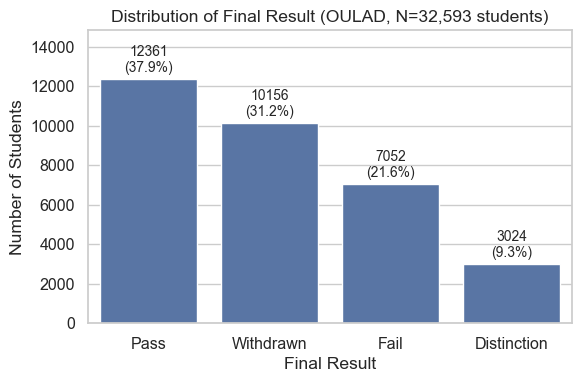

In [15]:
label_counts = info["final_result"].value_counts()
label_pct = (label_counts / label_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax, order=label_counts.index)
for i, (count, pct) in enumerate(zip(label_counts.values, label_pct.values)):
    ax.text(i, count + 200, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)
ax.set_title(f"Distribution of Final Result (OULAD, N={len(info):,} students)")
ax.set_xlabel("Final Result")
ax.set_ylabel("Number of Students")
ax.set_ylim(0, label_counts.max() * 1.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "q1_final_result_distribution.png", dpi=150)
plt.show()

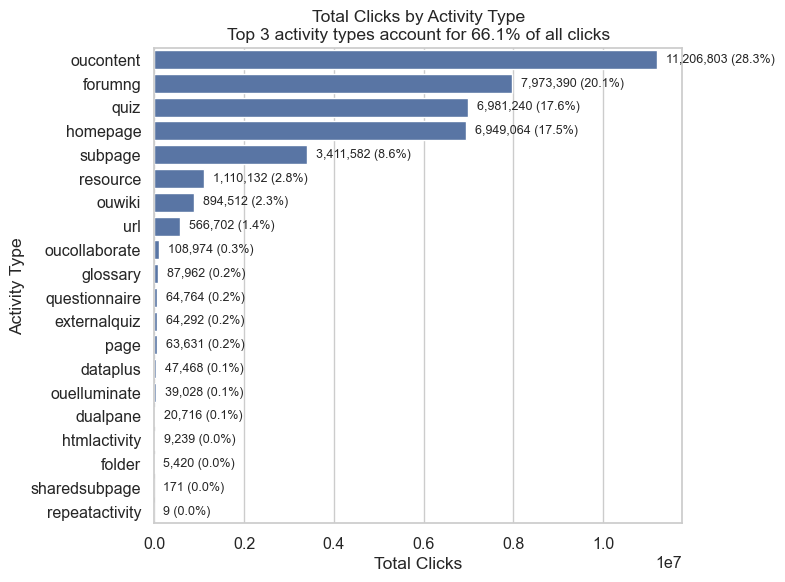

In [16]:
click_by_activity = (
    svle_clean.merge(vle[["id_site", "activity_type"]], on="id_site", how="left")
    .groupby("activity_type")["sum_click"].sum()
    .sort_values(ascending=False)
)
total_clicks = click_by_activity.sum()
top3_pct = click_by_activity.head(3).sum() / total_clicks * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=click_by_activity.values, y=click_by_activity.index, ax=ax, orient="h")
for i, v in enumerate(click_by_activity.values):
    ax.text(v + total_clicks * 0.005, i, f"{v:,} ({v/total_clicks*100:.1f}%)", va="center", fontsize=9)
ax.set_title(f"Total Clicks by Activity Type\nTop 3 activity types account for {top3_pct:.1f}% of all clicks")
ax.set_xlabel("Total Clicks")
ax.set_ylabel("Activity Type")
plt.tight_layout()
plt.savefig(FIG_DIR / "q2_clicks_by_activity_type.png", dpi=150)
plt.show()

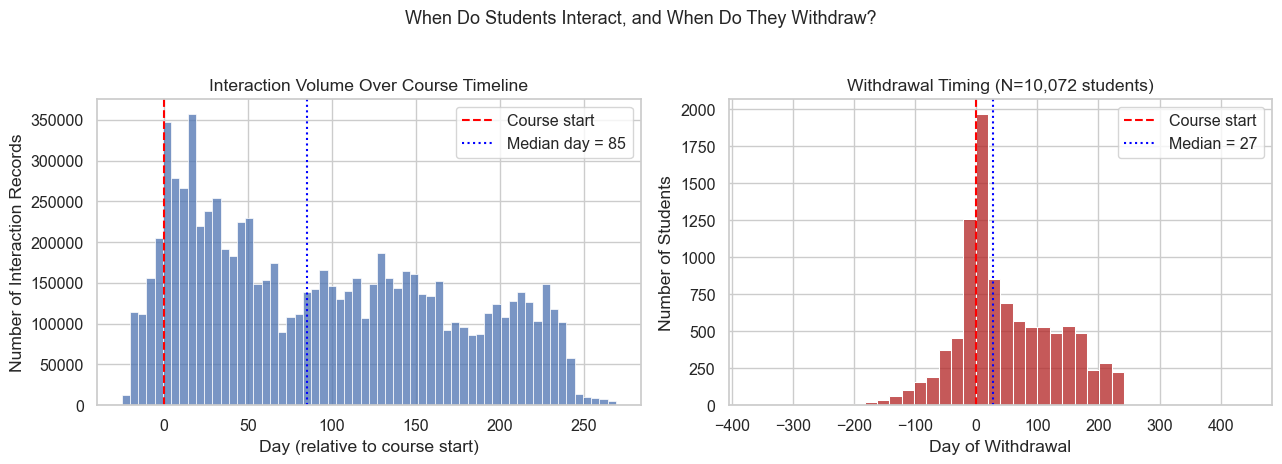

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(svle_clean["date"], bins=60, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", label="Course start")
median_day = svle_clean["date"].median()
axes[0].axvline(median_day, color="blue", linestyle=":", label=f"Median day = {median_day:.0f}")
axes[0].set_title("Interaction Volume Over Course Timeline")
axes[0].set_xlabel("Day (relative to course start)")
axes[0].set_ylabel("Number of Interaction Records")
axes[0].legend()

withdrawal_days = reg["date_unregistration"].dropna()
sns.histplot(withdrawal_days, bins=40, ax=axes[1], color="firebrick")
axes[1].axvline(0, color="red", linestyle="--", label="Course start")
axes[1].axvline(withdrawal_days.median(), color="blue", linestyle=":",
                label=f"Median = {withdrawal_days.median():.0f}")
axes[1].set_title(f"Withdrawal Timing (N={len(withdrawal_days):,} students)")
axes[1].set_xlabel("Day of Withdrawal")
axes[1].set_ylabel("Number of Students")
axes[1].legend()

fig.suptitle("When Do Students Interact, and When Do They Withdraw?", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "q3_timeline_and_withdrawal.png", dpi=150, bbox_inches="tight")
plt.show()

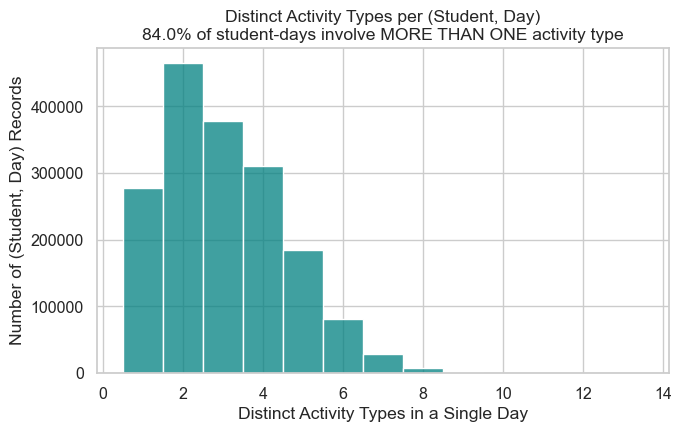

In [18]:
merged_all = svle_clean.merge(vle[["id_site", "activity_type"]], on="id_site", how="left")
daily_variety_all = merged_all.groupby(["id_student", "date"])["activity_type"].nunique()
pct_multi_activity = (daily_variety_all > 1).mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(daily_variety_all, bins=range(1, 10), discrete=True, ax=ax, color="teal")
ax.set_title(
    "Distinct Activity Types per (Student, Day)\n"
    f"{pct_multi_activity:.1f}% of student-days involve MORE THAN ONE activity type"
)
ax.set_xlabel("Distinct Activity Types in a Single Day")
ax.set_ylabel("Number of (Student, Day) Records")
plt.tight_layout()
plt.savefig(FIG_DIR / "q4_daily_activity_variety.png", dpi=150)
plt.show()

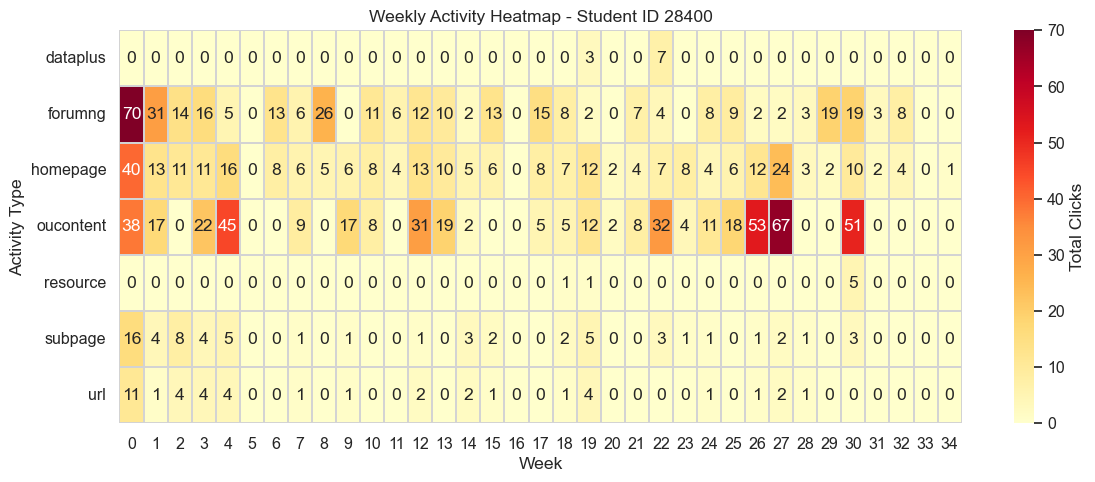

In [23]:
full_weeks = range(0, weekly.index.max() + 1)
weekly_full = weekly.reindex(full_weeks, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(weekly_full.T, cmap="YlOrRd", annot=True, fmt="d", ax=ax,
            cbar_kws={"label": "Total Clicks"}, linewidths=0.3, linecolor="lightgray")
ax.set_title(f"Weekly Activity Heatmap - Student ID {sample_id}")
ax.set_xlabel("Week")
ax.set_ylabel("Activity Type")
plt.tight_layout()
plt.savefig(FIG_DIR / "q5_sample_student_weekly_heatmap.png", dpi=150)
plt.show()